In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings("ignore")

from sklearn import metrics 
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
import pickle
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from model_classes import other_services
from scipy.stats import kruskal

import random
import os

Для воспроизводимости результата

In [2]:
# Фиксируем глобальные сиды
RANDOM_SEED = 42

np.random.seed( RANDOM_SEED )
random.seed( RANDOM_SEED )
os.environ[ 'PYTHONHASHSEED' ] = str( RANDOM_SEED )

Читаем нормализованные и частично обработанное по выбросам данные

In [3]:
df = pd.read_csv( 'data/regions_for_modeling.csv', index_col = 'region' )
df.head( 3 )

,population_norm,cost_of_living_all,disabled_total,disabled_60_,disabled_work,morbidity,poverty_socdem_16,poverty_socdem_retired,poverty_socdem_work,poverty_percent,...,crim_alco_nark_tox,crim_group,retail,regional_production,child_count,retired_count,lat,lon,child_mortality_newborn,drug_alco
region,,,,,,,,,,,,,,,,,,,,,
Алтайский край,2296353,10211,7.287,14.185,5.706,112764.7,5.495,1.610,10.395,17.5,...,0.4,0.046,1.25,3.03,21.3,33.0,53.3468,83.7768,0.9,0.005
Амурская область,781846,13530,7.950,16.452,6.489,83412.0,5.837,0.714,8.649,15.2,...,0.4,0.066,1.51,3.19,22.9,29.5,50.2839,127.5414,1.0,0.018
Архангельская область,1082662,13304,7.654,13.850,5.896,99842.1,3.506,0.886,7.909,12.3,...,0.4,0.098,1.57,3.84,20.9,37.6,64.5401,40.5433,0.8,0.007


Читаем признаки, по которым будем проводить обучение

In [4]:
df_features = pd.read_csv( 'data/features_for_modeling.csv' )
df_features.head( 20 )

,features_for_modeling
0,population_norm
1,disabled_work
2,poverty_socdem_16
3,poverty_socdem_retired
4,poverty_socdem_work
5,poverty_percent
6,welfare
7,per_capita
8,formal_wage
9,housing_Комнат


In [5]:
cols_for_modeling = df_features['features_for_modeling'].to_list()
df_model = df[ cols_for_modeling ].copy()
df_model.shape

(85, 14)

In [6]:
features = {
    "population_norm": ["Численность населения", "Числовой", ["низкая", "средняя", "высокая"] ],
    "cost_of_living_all": ["Прожиточный минимум за 4 квартал 2020г", "Числовой", ["низкий", "средний", "высокий"] ],
    "disabled_total": ["Число людей с инвалидностью, всего", "Числовой", ["низкое", "среднее", "высокое"] ],
    "disabled_60_": ["Число людей с инвалидностью, пенсионный возраст", "Числовой", ["низкое", "среднее", "высокое"] ],
    "disabled_work": ["Число людей с инвалидностью, трудоспособнй возраст", "Числовой", ["низкое", "среднее", "высокое"] ],
    "morbidity": ["Заболеваемость", "Числовой", ["низкая", "средняя", "высокая"] ],
    "poverty_socdem_16": ["процент людей, живущих за чертой бедности, подростки", "Числовой", ["низкий", "средний", "высокий"] ],
    "poverty_socdem_retired": ["процент людей, живущих за чертой бедности, пенсионеры", "Числовой", ["низкий", "средний", "высокий"] ],
    "poverty_socdem_work": ["процент людей, живущих за чертой бедности, трудоспособное население", "Числовой", ["низкий", "средний", "высокий"] ],
    "poverty_percent": ["процент людей, живущих за чертой бедности", "Числовой", ["низкий", "средний", "высокий"] ],
    "welfare": ["процент расходов на социальную политику от общих расходов бюджета региона", "Числовой", ["низкий", "средний", "высокий"] ],
    "per_capita": ["денежные доходы населения", "Числовой", ["низкие", "средние", "высокие"] ],
    "formal_wage": ["Номинальная зарплата", "Числовой", ["низкая", "средняя", "высокая"] ],
    "housing_Нет_стесненности": ["Стесненности в жилье", "Числовой", ["высокая", "средняя", "низкая"] ],
    "housing_Жилая_площадь": ["housing_Жилая площадь", "Числовой", ["низкая", "средняя", "высокая"] ],
    "housing_Комнат": ["Кол-во комнат", "Числовой", ["низкое", "среднее", "высокое"] ],
   
    "gross_regional_product": ["валовый региональный продукт на душу населения", "Числовой", ["низкий", "средний", "высокий"]  ],
    "crim_alco_nark_tox": ["Совершено преступлений в алкоголтьном или наркотическом опьянении", "Числовой", ["мало", "средне", "много"]  ],
    "retail": ["оборот розничной торговли на душу населения", "Числовой", ["низкий", "средний", "высокий"] ],
    "regional_production": ["объём отгруженных товаров или услуг", "Числовой", ["низкий", "средний", "высокий"] ],
    "child_mortality_newborn": ["Количество рождённых за вычетом смертности до 1 года",  "Числовой", ["низкое", "среднее", "высокое"] ],
    "drug_alco": ["Долевое количество акогольных и наркотических психозов", "Числовой", ["низкое", "среднее", "высокое"] ],
    
    "child_count": ["Численность населения подросткового возраста", "Числовой", ["низкая", "средняя", "высокая"] ],
    "retired_count": ["Численность населения пенсионного возраста", "Числовой", ["низкая", "средняя", "высокая"] ],
    "child_mortality_newborn": ["Разница рождаемости и смертности на 1м году жизни на 100 тыс. населения", "Числовой", ["низкая", "средняя", "высокая"] ],
    "crim_group": ["Совершено преступлений организованными группами на 100 тыс.человек населения", "Числовой", ["низкая", "средняя", "высокая"] ],
        
    "lat": ["Географическая широта региона", "Числовой", ["низкая", "средняя", "высокая"] ],
    "lon": ["Географическая долгота региона", "Числовой", ["низкая", "средняя", "высокая"] ]
}

## Моделирование

Поля после проектирования

In [7]:
columns = ['Измерение 1', 'Измерение 2']

### Baseline

In [8]:
preprocessing_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA( n_components = 2, random_state = RANDOM_SEED ) )
])

df_model_scalled_compressed = preprocessing_pipeline.fit_transform( df_model )
print( f"{df_model_scalled_compressed.shape[1]} главных компоненты объясняет долю дисперсии исходных данных {round( sum( preprocessing_pipeline['pca'].explained_variance_ratio_ ), 2 )}, до проекции: {df_model.shape[1]} признаков, после: {df_model_scalled_compressed.shape[1]}")

df_model_scalled_compressed_PCA = pd.DataFrame( df_model_scalled_compressed, columns = columns )

2 главных компоненты объясняет долю дисперсии исходных данных 0.7, до проекции: 14 признаков, после: 2


In [9]:
df_model.shape

(85, 14)

### t-SNE

Сделает автоподбор perplexity по метрика Калински-Харабаса, введя мягкий штраф за расползание кластеров (те за шумы)

In [10]:
best_arg = 0  # Максимизируемый параметр
best_cluster = 3 # Начальное количество кластеров
best_perplexity = 5 # Начальный best_perplexity

tmp_df_scalled = MinMaxScaler().fit_transform( df_model )
for perplexity in range( 5, 25 ):
    tmp_df = TSNE( n_components = 2, perplexity = perplexity, random_state = RANDOM_SEED ).fit_transform( tmp_df_scalled )
    for cluster in range(3,11):
        model = KMeans( n_clusters = cluster, random_state = RANDOM_SEED ).fit( tmp_df )
        cal = metrics.calinski_harabasz_score( tmp_df, model.labels_ )
        
        if cal / cluster / np.log( cluster ) > best_arg:
            print(f"Новый оптимум ===> Кластеров: {cluster}, Perplexity: {perplexity:2}, Score: {round(cal, 4):.4f} (метрика Калински-Харабаса: {round( cal, 2 ):.2f})")
            best_arg = cal / cluster / np.log( cluster )
            best_cluster = cluster
            best_perplexity = perplexity

print(f"\nИтог -> Кластеров: {best_cluster}, Perplexity: {best_perplexity}")       

Новый оптимум ===> Кластеров: 3, Perplexity:  5, Score: 119.4722 (метрика Калински-Харабаса: 119.47)
Новый оптимум ===> Кластеров: 3, Perplexity:  6, Score: 142.1220 (метрика Калински-Харабаса: 142.12)
Новый оптимум ===> Кластеров: 3, Perplexity:  7, Score: 157.6835 (метрика Калински-Харабаса: 157.68)

Итог -> Кластеров: 3, Perplexity: 7


In [11]:
perplexity = best_perplexity # 1= ==> 24 # ===> 15 #17
pipeline = Pipeline(
    [
        ('scaler', MinMaxScaler()),
        ('t-SNE', TSNE( n_components = 2, perplexity = perplexity, random_state = RANDOM_SEED ))
    ]
)

X_model_scalled_compressed_tSNE = pipeline.fit_transform( df_model )
print( f"Значение дивергенции Кульбака — Лейблера для обученного алгоритма t-SNE: {round(pipeline[1].kl_divergence_, 2)} " )
df_model_scalled_compressed_tSNE = pd.DataFrame( X_model_scalled_compressed_tSNE, columns = columns )

Значение дивергенции Кульбака — Лейблера для обученного алгоритма t-SNE: 0.58 


Сравним графики обоих подходов

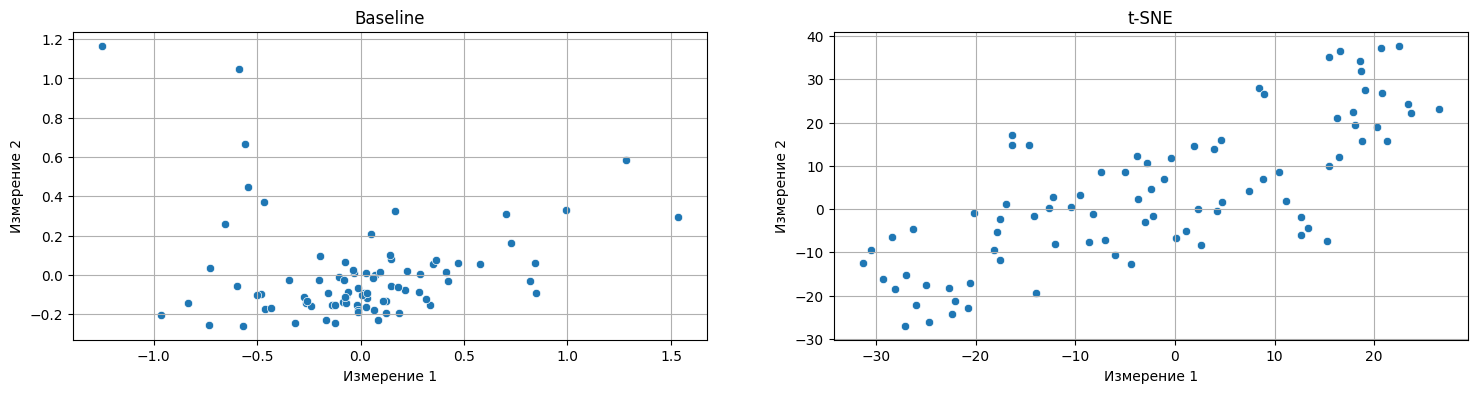

In [12]:
fig, axes = plt.subplots( 1, 2, figsize = (18, 4) )

fig0 = sns.scatterplot( data  = df_model_scalled_compressed_PCA, x = df_model_scalled_compressed_PCA.iloc[:,0], y = df_model_scalled_compressed_PCA.iloc[:,1], ax = axes[0] )
fig0.set_title( "Baseline" )
fig0.grid()

fig1 = sns.scatterplot( data  = df_model_scalled_compressed_tSNE, x = df_model_scalled_compressed_tSNE.iloc[:,0], y = df_model_scalled_compressed_tSNE.iloc[:,1], ax = axes[1] )
fig1.set_title( "t-SNE" )
fig1.grid()

plt.show()

t-SNE предлагает немного лучшее разбиение на кластеры

Определим callback'и для единообразного расчета метрик по модели и количеству кластеров

Рассматриваем модели KMeans, GaussianMixture, SpectralClustering, AgglomerativeClustering

In [13]:
################################################################################################
#
# Возвращает метрики модели
#
# Вход: 
#    df - Датасет
#    labels - метки кластеров
#
# Выход: метрики Силуэта, Калински-Харабаса, Дэвиса-Болдина и метки кластеров
#
################################################################################################
def get_metrics( df, labels ):
    sil = metrics.silhouette_score( df, labels, metric = 'euclidean' ) 
    cal = metrics.calinski_harabasz_score( df, labels )  
    dav = metrics.davies_bouldin_score( df, labels  )     
    
    return sil, cal, dav, labels


################################################################################################
# 
# Действие:
# -  Обучает модель (KMeans, GaussianMixture, SpectralClustering, AgglomerativeClustering)
# -  Расчитывает метрики расчитанной модели
#
# Вход: 
#    df - Датасет
#    cluster_num - Количество кластеров
#    hdr - Подпись на графике
#
# Выход: Количество кластеров и соответствующие метрики (Силуэта, Калински-Харабаса, Дэвиса-Болдина )
#
################################################################################################
def callback_metrics_KMeans( cluster_num, df ):
    model = KMeans( n_clusters = cluster_num, random_state = RANDOM_SEED ).fit( df )
    return get_metrics( df, model.labels_ )


def callback_metrics_GaussianMixture( cluster_num, df ):
    model = GaussianMixture( n_components = cluster_num, random_state = RANDOM_SEED, covariance_type = 'tied' ).fit( df )
    prediction = model.predict( df )
    return get_metrics( df, prediction )


def callback_metrics_SpectralClustering( cluster_num, df ):
    model =  SpectralClustering( n_clusters = cluster_num, random_state = RANDOM_SEED ).fit( df )
    return get_metrics( df, model.labels_ )


def callback_metrics_AgglomerativeClustering( cluster_num, df ):
    model =  AgglomerativeClustering( n_clusters = cluster_num ).fit( df )
    return get_metrics( df, model.labels_ )

Функции для унифицированного сохранения результатов замеров в словарь

In [14]:
################################################################################################
# 
# Действие:
# -  Обучает модель, переданную через callback
# -  Расчитывает метрики расчитанной модели
# -  Возвращает оптимальное количество кластеров (в отрезке от 3 до  10) и соответствующую метрику
# -  Рисует графики метрик в зависимости от количества кластеров (в отрезке от 3 до  10)
#
# Вход: 
#    df - Датасет
#    callback_metric_model - callback модели
#    hdr - Подпись на графике
#
# Выход: Количество кластеров и соответствующие метрики (Силуэта, Калински-Харабаса, Дэвиса-Болдина )
#
################################################################################################
def plot_metrics( df, callback_metric_model, hdr ):
    silhouettes_list = []
    calinski_harabasz_list = []
    davis_bouldin_list = [] 
    
    best_sil = -1
    best_cal = 0
    best_dav = np.inf
    
    min_cluster_num = 3
    max_cluster_num = 10
    cluster_range = range( min_cluster_num, max_cluster_num + 1 )
    
    best_sil_clusters = min_cluster_num
    best_cal_clusters = min_cluster_num
    best_dav_clusters = min_cluster_num
    
    best_labels_sil = None
    best_labels_cal = None
    best_labels_dav = None
    
    # перебираем количество от 3 до max_cluster_num включительно
    for clusters in cluster_range:
        sil, cal, dav, labels = callback_metric_model( cluster_num = clusters, df = df )
        silhouettes_list.append( sil )
        calinski_harabasz_list.append( cal )
        davis_bouldin_list.append( dav ) 
        
        if best_sil < sil:
            best_sil = sil
            best_sil_clusters = clusters
            best_labels_sil = labels
        
        if best_cal < cal:
            best_cal = cal
            best_cal_clusters = clusters
            best_labels_cal = labels
            

        if best_dav > dav:
            best_dav = dav
            best_dav_clusters = clusters
            best_labels_dav = labels
      
    print( hdr )
    
    # строим графики для выбранных метрик для выбора количества кластеров   
    fig, ax = plt.subplots( 1, 3, figsize = (24,5) )
        
    ax[0].plot( cluster_range, silhouettes_list, 'xb-', label = 'Коэффициент силуэта' )
    ax[1].plot( cluster_range, calinski_harabasz_list, 'xb-', label = 'Индекс Калински — Харабаса' )
    ax[2].plot( cluster_range, davis_bouldin_list, 'xb-', label = 'Индекс Дэвиса — Болдина' )
    ax[0].legend( prop = {'size': 16} )
    ax[1].legend( prop = {'size': 16} )
    ax[2].legend( prop = {'size': 16} )
    plt.show()
    
    best_sil_clusters = round( best_sil_clusters, 2 )
    best_cal_clusters = round( best_cal_clusters, 2 )
    best_dav_clusters = round( best_dav_clusters, 2 )
    
    print( f"Максимальное значение коэффициента Силуэта: {round( best_sil, 3 )} при количестве кластеров {best_sil_clusters}" )
    print( f"Максимальное значение коэффициента Калински-Харабаса: {round( best_cal, 3 )} при количестве кластеров {best_cal_clusters}" )
    print( f"Минимальное значение коэффициента Дэвиса-Болдина: {round( best_dav, 3 )} при количестве кластеров {best_dav_clusters}" )  
        
    return [best_sil_clusters, best_cal_clusters, best_dav_clusters, best_sil, best_cal, best_dav, best_labels_sil, best_labels_cal, best_labels_dav]

----------------------------------------
СТАРТ АВТОМАТИЧЕСКОГО ПОДБОРА ПАРАМЕТРОВ
----------------------------------------
Начальное значение коэффициента силуэта: -1 при количестве кластеров 3
Начальное значение коэффициента Калински-Харабаса: 0 при количестве кластеров 3
Начальное значение коэффициента Дэвиса-Болдина: inf при количестве кластеров 3

PCA + KMeans


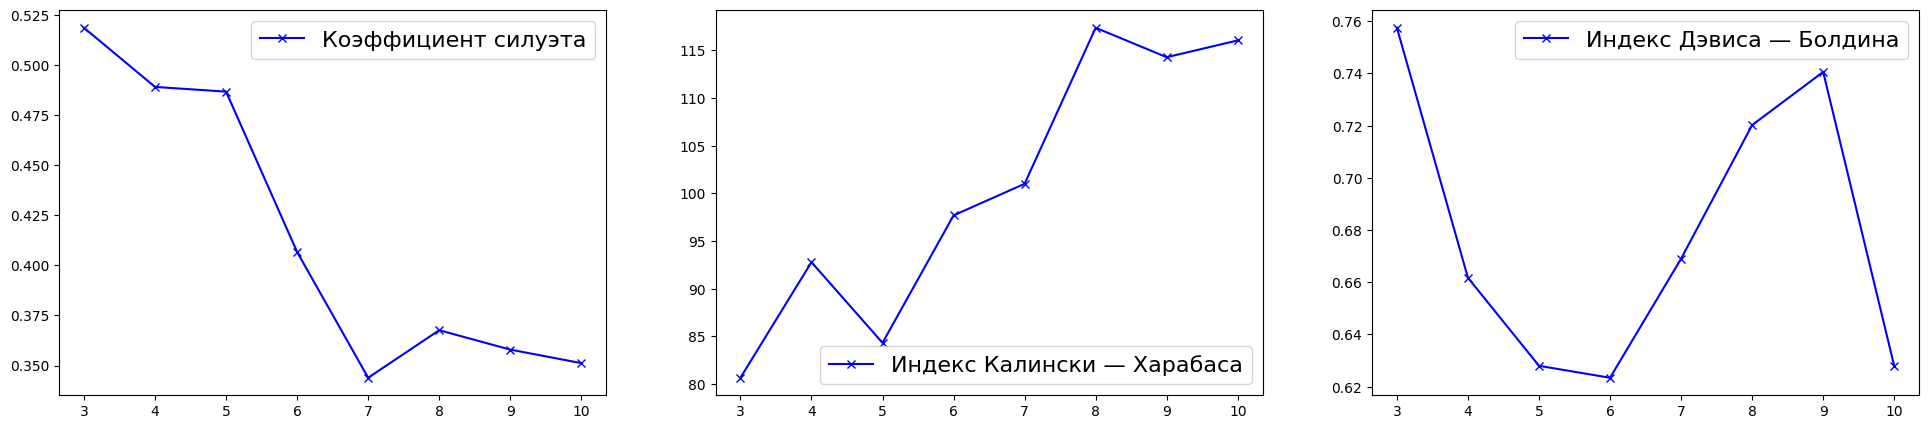

Максимальное значение коэффициента Силуэта: 0.519 при количестве кластеров 3
Максимальное значение коэффициента Калински-Харабаса: 117.353 при количестве кластеров 8
Минимальное значение коэффициента Дэвиса-Болдина: 0.623 при количестве кластеров 6
==>>> Улучшаем Силуэт: -1 <== 0.519 при PCA KMeans, кластеров: 3
==>>> Улучшаем Калински-Харабаса: 0 <== 117.353 при PCA KMeans, кластеров: 8
==>>> Улучшаем Дэвиса-Болдина: inf <== 0.623 при PCA KMeans, кластеров: 6


PCA + GaussianMixture


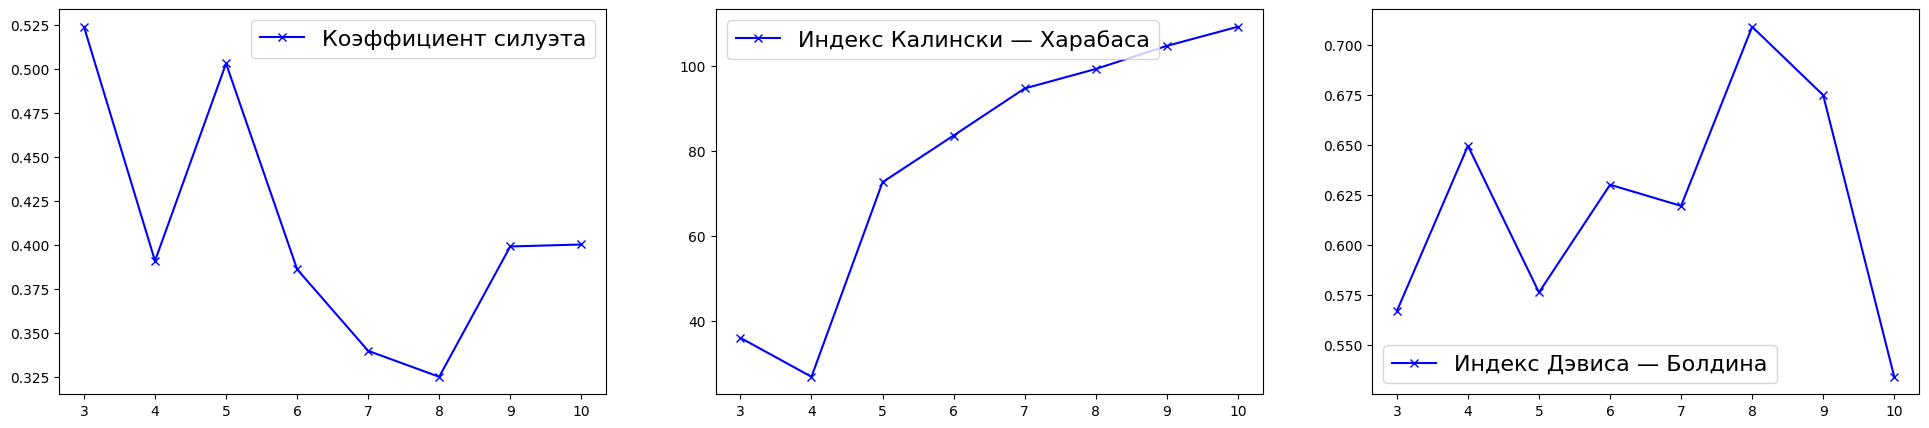

Максимальное значение коэффициента Силуэта: 0.524 при количестве кластеров 3
Максимальное значение коэффициента Калински-Харабаса: 109.173 при количестве кластеров 10
Минимальное значение коэффициента Дэвиса-Болдина: 0.534 при количестве кластеров 10
==>>> Улучшаем Силуэт: 0.519 <== 0.524 при PCA GaussianMixture, кластеров: 3
==>>> Улучшаем Дэвиса-Болдина: 0.623 <== 0.534 при PCA GaussianMixture, кластеров: 10


PCA + SpectralClustering


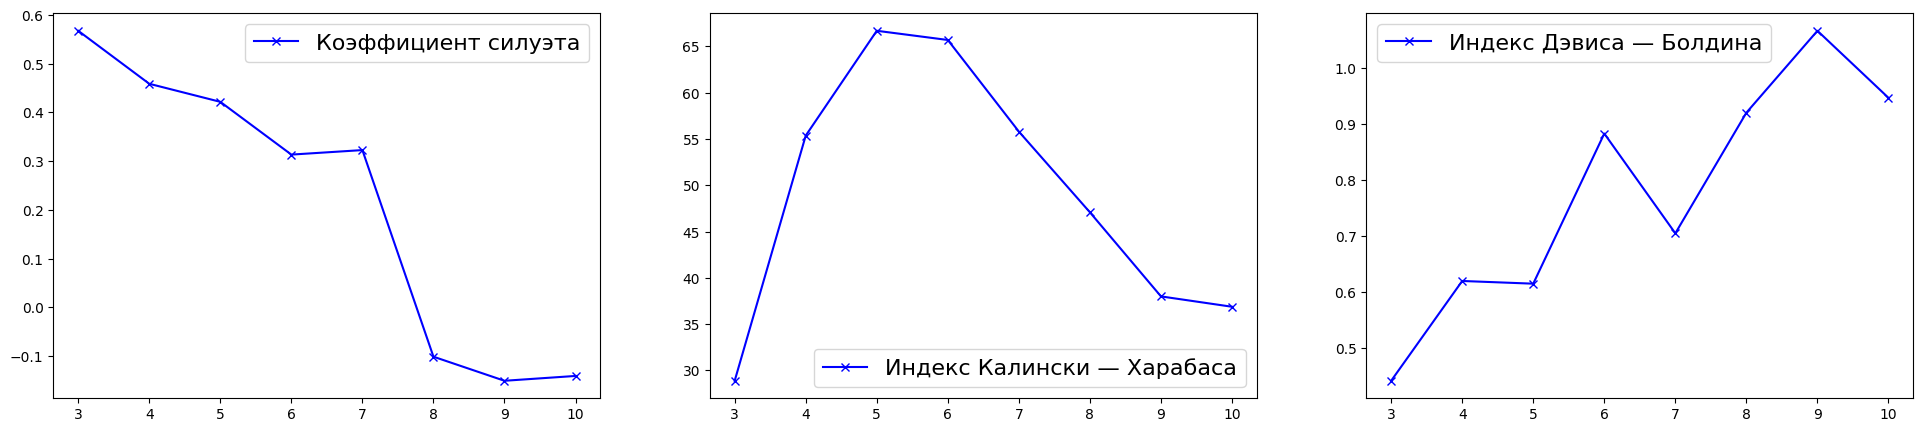

Максимальное значение коэффициента Силуэта: 0.568 при количестве кластеров 3
Максимальное значение коэффициента Калински-Харабаса: 66.691 при количестве кластеров 5
Минимальное значение коэффициента Дэвиса-Болдина: 0.442 при количестве кластеров 3
==>>> Улучшаем Силуэт: 0.524 <== 0.568 при PCA SpectralClustering, кластеров: 3
==>>> Улучшаем Дэвиса-Болдина: 0.534 <== 0.442 при PCA SpectralClustering, кластеров: 3


PCA + AgglomerativeClustering


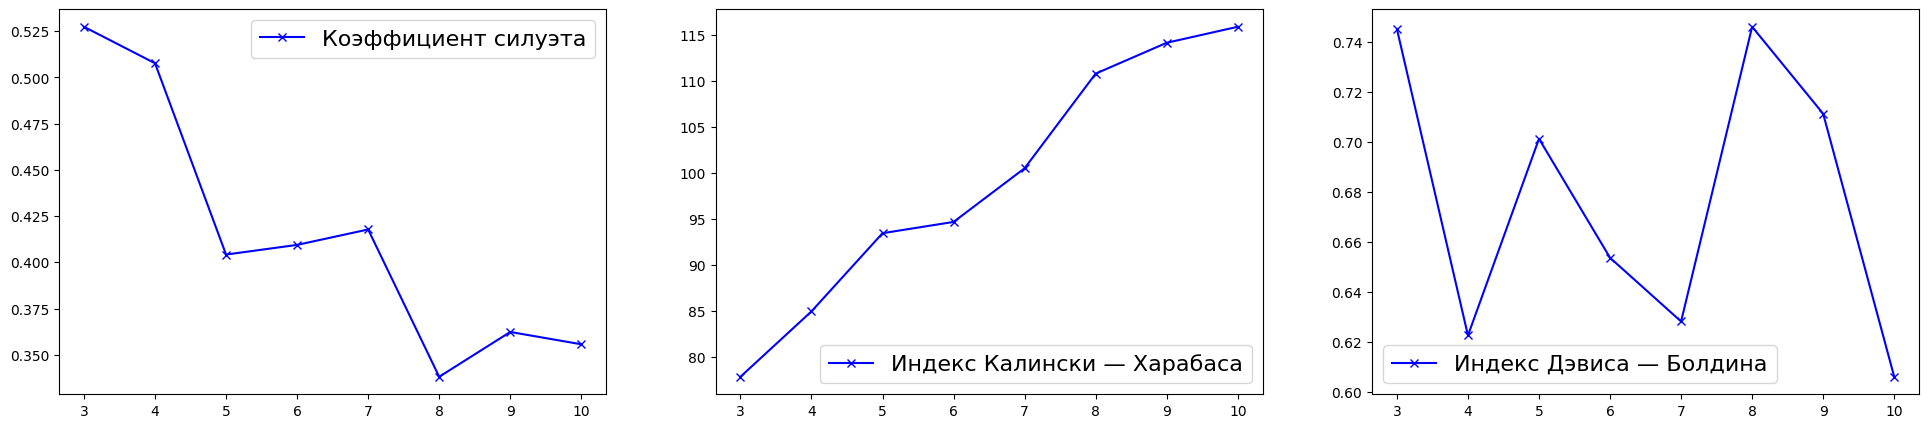

Максимальное значение коэффициента Силуэта: 0.527 при количестве кластеров 3
Максимальное значение коэффициента Калински-Харабаса: 115.879 при количестве кластеров 10
Минимальное значение коэффициента Дэвиса-Болдина: 0.606 при количестве кластеров 10
t-SNE + KMeans


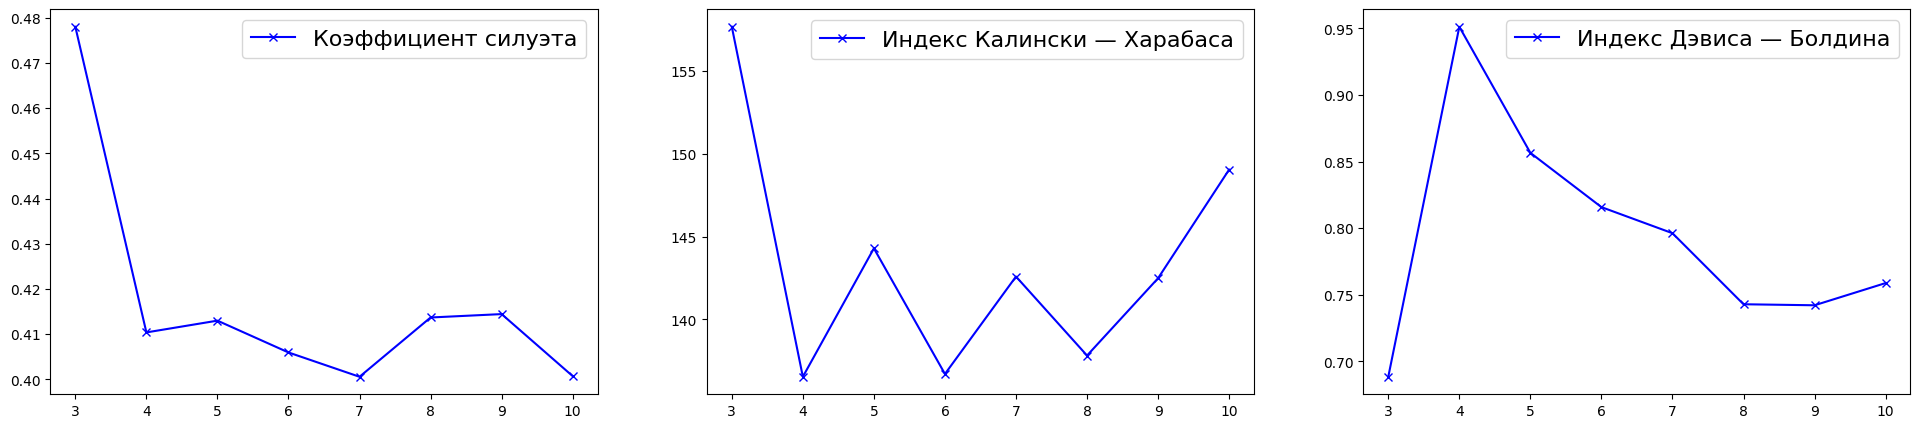

Максимальное значение коэффициента Силуэта: 0.478 при количестве кластеров 3
Максимальное значение коэффициента Калински-Харабаса: 157.683 при количестве кластеров 3
Минимальное значение коэффициента Дэвиса-Болдина: 0.688 при количестве кластеров 3
==>>> Улучшаем Калински-Харабаса: 117.353 <== 157.683 при t-SNE KMeans, кластеров: 3


t-SNE + GaussianMixture


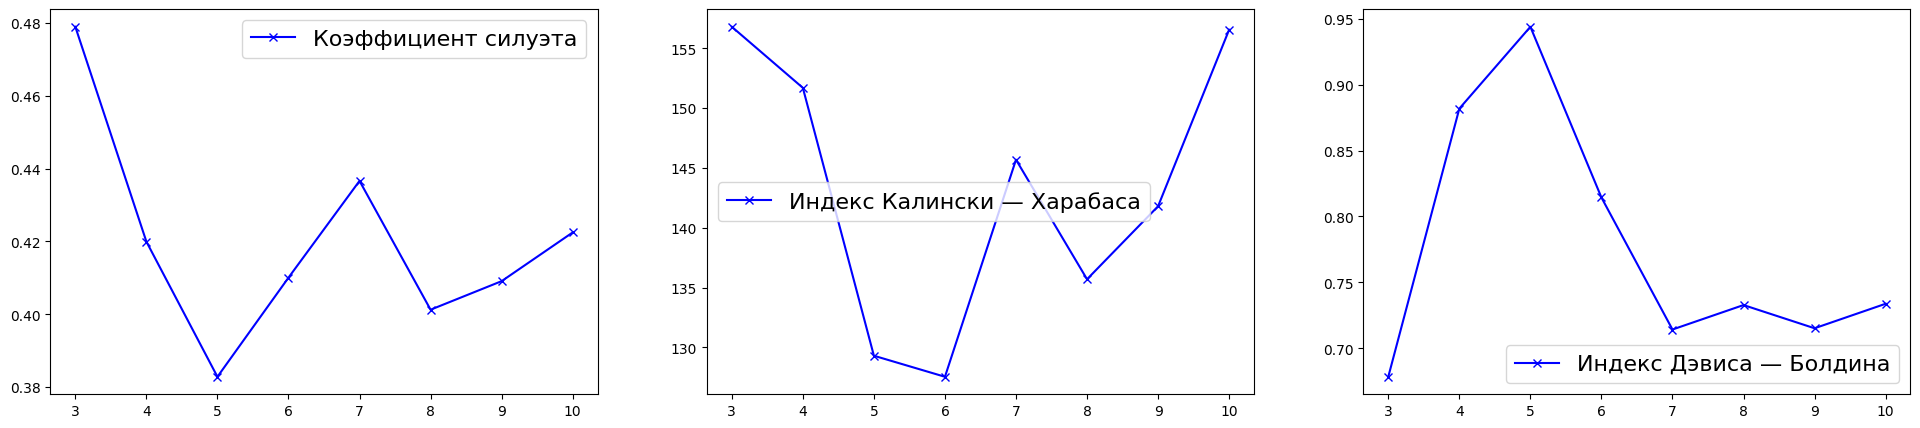

Максимальное значение коэффициента Силуэта: 0.479 при количестве кластеров 3
Максимальное значение коэффициента Калински-Харабаса: 156.804 при количестве кластеров 3
Минимальное значение коэффициента Дэвиса-Болдина: 0.678 при количестве кластеров 3
t-SNE + SpectralClustering


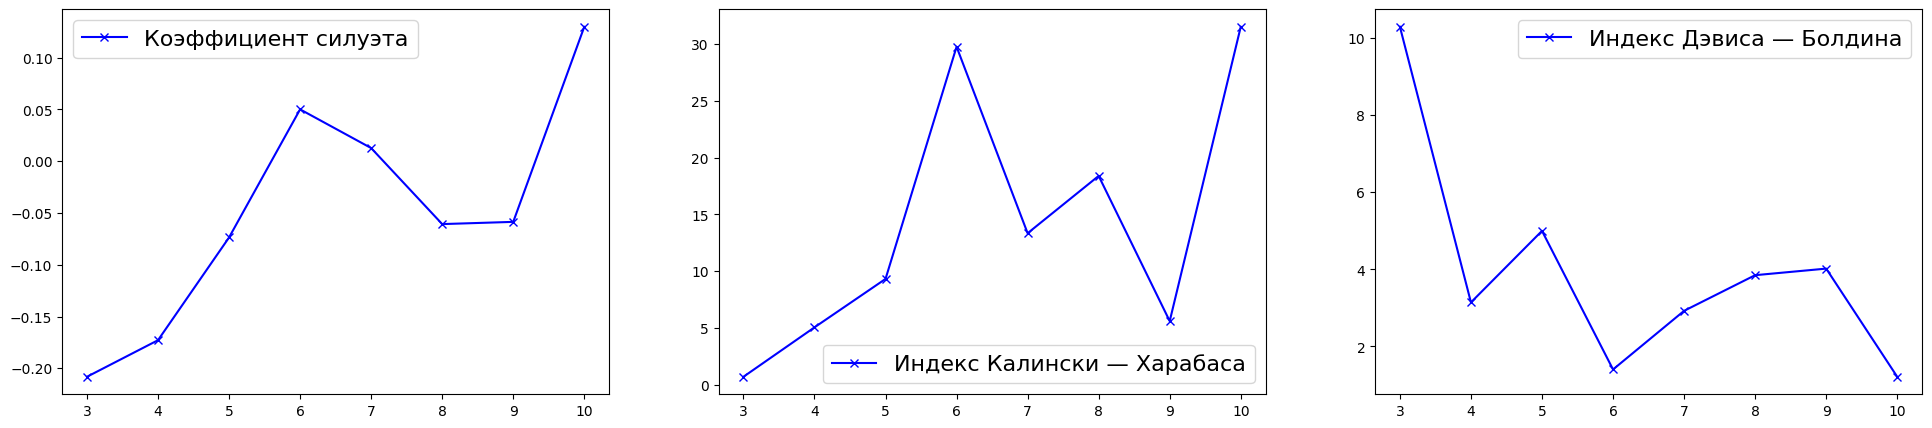

Максимальное значение коэффициента Силуэта: 0.13 при количестве кластеров 10
Максимальное значение коэффициента Калински-Харабаса: 31.532 при количестве кластеров 10
Минимальное значение коэффициента Дэвиса-Болдина: 1.21 при количестве кластеров 10
t-SNE + AgglomerativeClustering


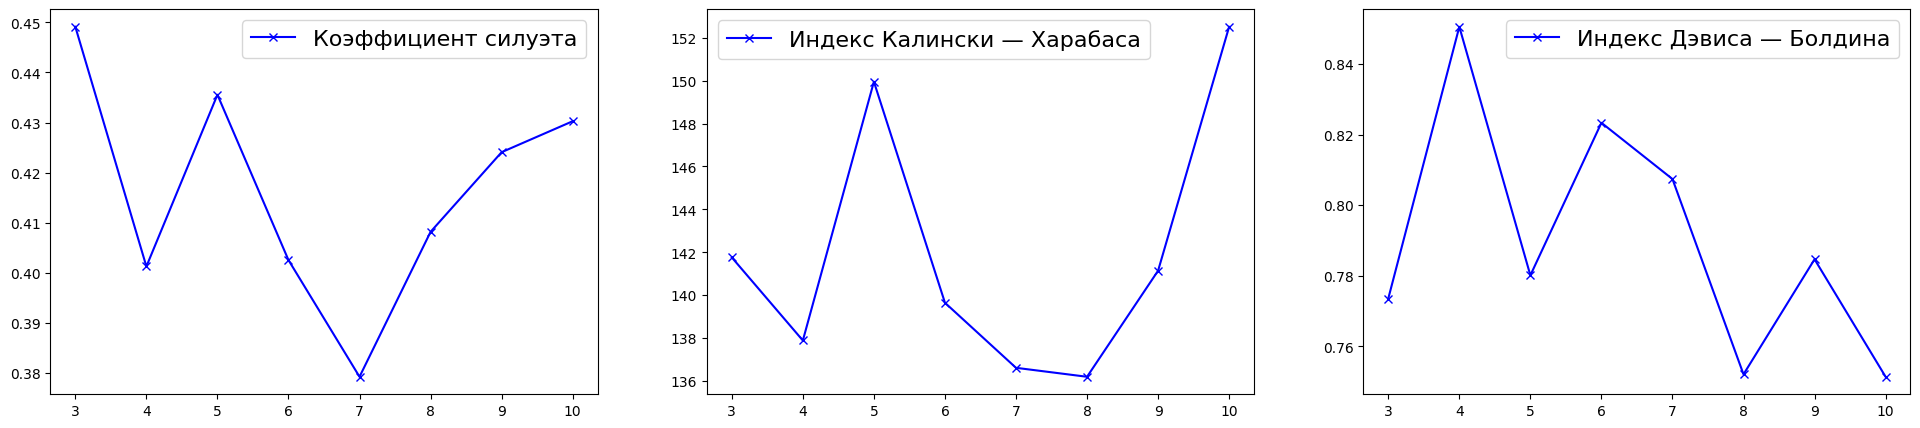

Максимальное значение коэффициента Силуэта: 0.449 при количестве кластеров 3
Максимальное значение коэффициента Калински-Харабаса: 152.508 при количестве кластеров 10
Минимальное значение коэффициента Дэвиса-Болдина: 0.751 при количестве кластеров 10

---------------------------------------------------------
ИТОГ АВТОМАТИЧЕСКОГО ПОДБОРА ПАРАМЕТРОВ (ИМЕЕМ КАНДАДАТЫ)
---------------------------------------------------------
Максимальное значение коэффициента силуэта: 0.568 при количестве кластеров 3, PCA + SpectralClustering
Максимальное значение коэффициента Калински-Харабаса: 157.683 при количестве кластеров 3, t-SNE + KMeans
Минимальное значение коэффициента Дэвиса-Болдина: 0.442 при количестве кластеров 3, PCA + SpectralClustering


,sil,cal,dav
0,0.568,157.683,0.442
1,3,3,3
2,PCA,t-SNE,PCA
3,SpectralClustering,KMeans,SpectralClustering
4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 0, 0, 2, 1, 0, 0, 0, 0, 1, 2, 2, 0, 2, 2, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,Силуэт,Калински-Харабас,Дэвис-Болдин


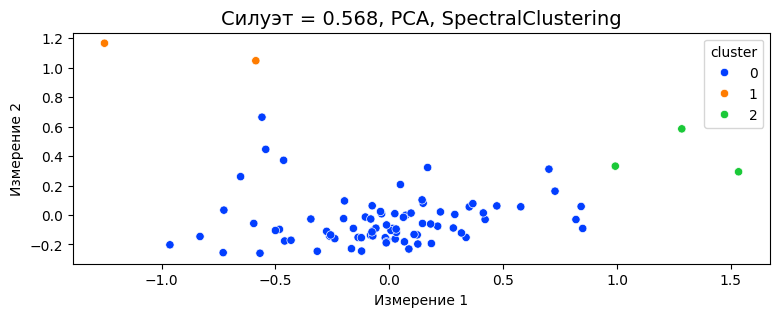

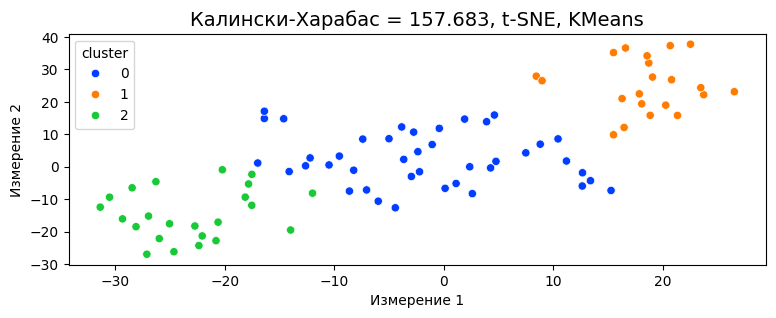

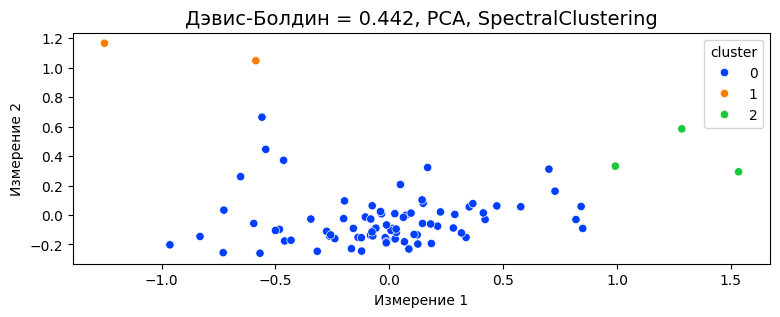

In [15]:
metrics_list = [KMeans, GaussianMixture, SpectralClustering, AgglomerativeClustering]

# Словарь датасетов
datasets = { "PCA": df_model_scalled_compressed_PCA, "t-SNE": df_model_scalled_compressed_tSNE }

# Словарь моделей и callback'ов
models = {
    "KMeans": [callback_metrics_KMeans],
    "GaussianMixture": [callback_metrics_GaussianMixture],
    "SpectralClustering": [callback_metrics_SpectralClustering],
    "AgglomerativeClustering": [callback_metrics_AgglomerativeClustering]
}

keys = ["Коэффициент", "Кластеров", "Датафрейм", "Модель"]

# Словарь оптимальных настроек
best_params = {}
best_params["sil"] = [-1, 3, None, None]
best_params["cal"] = [0, 3, None, None]
best_params["dav"] = [np.inf, 3, None, None]

print( "----------------------------------------" )
print( "СТАРТ АВТОМАТИЧЕСКОГО ПОДБОРА ПАРАМЕТРОВ" )
print( "----------------------------------------" )
print( f"Начальное значение коэффициента силуэта: {round( best_params['sil'][0], 3 )} при количестве кластеров {best_params['sil'][1]}" )
print( f"Начальное значение коэффициента Калински-Харабаса: {round( best_params['cal'][0], 3 )} при количестве кластеров {best_params['cal'][1]}" )
print( f"Начальное значение коэффициента Дэвиса-Болдина: {round( best_params['dav'][0], 3 )} при количестве кластеров {best_params['dav'][1]}" )  
print()

###################################### Первичный автоподбор параметров ######################################
for tmp_df_type in datasets:
    for model in models:
        sil_clusters, cal_clusters, dav_clusters, sil_metric, cal_metric, dav_metric, sil_labels, cal_labels, dav_labels = plot_metrics( df = datasets[tmp_df_type], callback_metric_model = models[ model ][ 0 ], hdr = f"{tmp_df_type} + {model}" )
       
        flag_best = False
        if best_params["sil"][0]  < sil_metric:
            print( f"==>>> Улучшаем Силуэт: {round( best_params['sil'][0] , 3 )} <== {round( sil_metric, 3 )} при {tmp_df_type} {model}, кластеров: {sil_clusters}" )
            best_params["sil"] = [sil_metric, sil_clusters, tmp_df_type, model, sil_labels, "Силуэт"]
            flag_best = True
            
        if best_params["cal"][0] < cal_metric:
            print( f"==>>> Улучшаем Калински-Харабаса: {round( best_params['cal'][0], 3 )} <== {round( cal_metric, 3 )} при {tmp_df_type} {model}, кластеров: {cal_clusters}" )
            best_params["cal"] = [cal_metric, cal_clusters, tmp_df_type, model, cal_labels, "Калински-Харабас"]
            flag_best = True
        
        if best_params["dav"][0] > dav_metric:
            print( f"==>>> Улучшаем Дэвиса-Болдина: {round( best_params['dav'][0], 3 )} <== {round( dav_metric, 3 )} при {tmp_df_type} {model}, кластеров: {dav_clusters}" )
            best_params["dav"] = [dav_metric, dav_clusters, tmp_df_type, model, dav_labels, "Дэвис-Болдин"]
            flag_best = True
            
        if flag_best:
            print( "\n" )

best_params["sil"][0] = round( best_params["sil"][0], 3 )
best_params["cal"][0] = round( best_params["cal"][0], 3 )
best_params["dav"][0] = round( best_params["dav"][0], 3 )
    
print()
print( "---------------------------------------------------------" )
print( "ИТОГ АВТОМАТИЧЕСКОГО ПОДБОРА ПАРАМЕТРОВ (ИМЕЕМ КАНДАДАТЫ)" )
print( "---------------------------------------------------------" )
print( f"Максимальное значение коэффициента силуэта: {best_params['sil'][0]} при количестве кластеров {best_params['sil'][1]}, {best_params['sil'][2]} + {best_params['sil'][3]}" )
print( f"Максимальное значение коэффициента Калински-Харабаса: {best_params['cal'][0]} при количестве кластеров {best_params['cal'][1]}, {best_params['cal'][2]} + {best_params['cal'][3]}" )
print( f"Минимальное значение коэффициента Дэвиса-Болдина: {best_params['dav'][0]} при количестве кластеров {best_params['dav'][1]}, {best_params['dav'][2]} + {best_params['dav'][3]}" )  

###################################### Отобразим промежуточный итог ######################################
df_metrics_table =  pd.DataFrame.from_dict( best_params, orient = 'index' ).T 
display( df_metrics_table )

# Отобразим разделение
for i, metric in enumerate( ['sil','cal','dav'] ):
    fig = plt.figure( figsize = (9,3) )
    df_plot = datasets[ best_params[ metric ][2] ].copy() # Извлечем оптимальный датасет
    df_plot['cluster'] = best_params[ metric ][4] # Проставим метки
    
    sns.scatterplot( x = df_plot.iloc[:,0], y = df_plot.iloc[:,1], hue = df_plot['cluster'], palette = 'bright')
    plt.title( f"{best_params[metric][5]} = {best_params[metric][0]}, {best_params[metric][2]}, {best_params[metric][3]}", fontsize = 14  )
    plt.show()

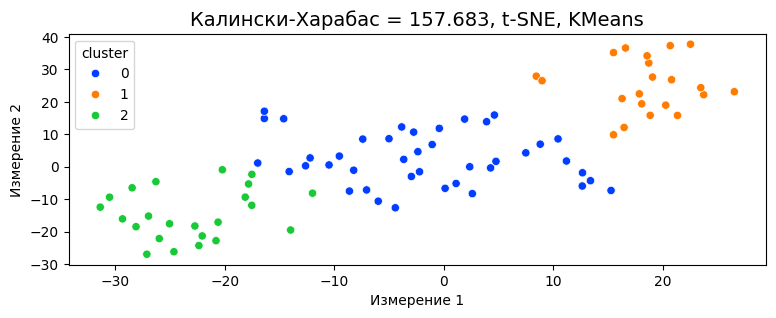

In [16]:
best_clusters = 3
best_model = 'KMeans'
best_dataset = 't-SNE'
best_ind = 'cal'

fig = plt.figure( figsize = (9,3) )
df_plot = datasets[ best_params[ best_ind ][2] ].copy() # Извлечем оптимальный датасет
df_plot['cluster'] = best_params[ best_ind ][4] # Проставим метки

sns.scatterplot( x = df_plot.iloc[:,0], y = df_plot.iloc[:,1], hue = df_plot['cluster'], palette = 'bright')
plt.title( f"{best_params[best_ind][5]} = {best_params[best_ind][0]}, {best_params[best_ind][2]}, {best_params[best_ind][3]}", fontsize = 14  )
plt.show()

In [17]:
n_clusters = best_clusters

In [18]:
best_dataset, best_clusters, best_model

('t-SNE', 3, 'KMeans')

## Интерпритация результата

In [19]:
from sklearn.compose import ColumnTransformer
from model_classes import plot_model_clusters, PipelineTSNE, PipelineSpectralClustering, PipelineAgglomerativeClustering

Динамически генерируем pileline

In [20]:
if best_dataset == 't-SNE':
    callback_step_proection = PipelineTSNE
    callback_step_proection_args = { "n_components": 2, "random_state": RANDOM_SEED, "perplexity": perplexity}
else:
    callback_step_proection = PCA
    callback_step_proection_args = { "n_components": 2, "random_state": RANDOM_SEED }
    
if best_model == 'KMeans':
    callback_step_model = KMeans
    callback_step_model_args = { "n_clusters": n_clusters, "random_state": RANDOM_SEED }
    
elif best_model == 'GaussianMixture':
    callback_step_model = GaussianMixture 
    callback_step_model_args = { "n_clusters": n_clusters, "random_state": RANDOM_SEED, "covariance_type": 'tied' }
    
elif best_model == 'SpectralClustering':
    callback_step_model = PipelineSpectralClustering
    callback_step_model_args = { "n_clusters": n_clusters, "random_state": RANDOM_SEED }
    
else:
    callback_step_model = PipelineAgglomerativeClustering
    callback_step_model_args = { "n_clusters": n_clusters }
        
pipeline_production = Pipeline([
    ('preprocessing', ColumnTransformer( transformers = [ ('keep', 'passthrough', cols_for_modeling) ] )), # Удалим признаки, не входящие в cols_for_modeling
    ('scaler', MinMaxScaler()), # Масштабируем
    ('proection', callback_step_proection( **callback_step_proection_args )),  # Проектируем в 2d
    ('model', callback_step_model( **callback_step_model_args ) ) # Моделируем
])

# Берем первичный файл (те с самого начала повторяем шаги)
pipeline_production.fit( df ) # Обучаем pipeline

# Сохраним модель в формате pickle-файла
with open('model/model_regions.pkl', 'wb') as pkl_file:
    pickle.dump( pipeline_production, pkl_file)

pipeline_production

,steps,"[('preprocessing', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('keep', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Давайте посмотрим эти поля в графиках. Они - сводные и информативные

Предскажем кластеры и отрисуем

In [21]:
cols_for_draw = [
    'population_norm', 'disabled_total', 'morbidity', 'poverty_percent', 'welfare', 'per_capita', 'retail', 
    'gross_regional_product', 'regional_production', 'housing_Жилая_площадь', 
    'child_mortality_newborn', 'crim_group' #, 'cluster'
]

pd.DataFrame( data = {"cols_for_draw": cols_for_draw} ).to_csv( "data/cols_for_draw.csv", index = None )

In [22]:
# Предскажем кластеры
tmp_df = df[ cols_for_draw ].copy()
tmp_df['cluster'] = pipeline_production.predict( df )

obj_plot_model_clusters = plot_model_clusters( tmp_df, tmp_df['cluster'].nunique() )
obj_plot_model_clusters.plot_cluster_all()
obj_plot_model_clusters.plot_cluster_by_one()

,population_norm,disabled_total,morbidity,poverty_percent,welfare,per_capita,retail,gross_regional_product,regional_production,housing_Жилая_площадь,child_mortality_newborn,crim_group
0,0.306287,1.000000,1.000000,0.416667,0.75,0.312977,0.386667,0.288079,0.290909,0.777778,0.000000,1.0
1,1.000000,0.000000,0.634528,0.000000,0.00,1.000000,1.000000,1.000000,1.000000,0.000000,0.666667,0.0
2,0.000000,0.798491,0.000000,1.000000,1.00,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.4


In [23]:
with open( 'model/model_regions.pkl', 'rb' ) as pkl_file:
    model_from_file = pickle.load( pkl_file )
    
model_from_file

,steps,"[('preprocessing', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('keep', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Проверим, что результаты исходного и десериализованного пайплайнов и идентичны

In [24]:
print( all( pipeline_production.predict( df ) == model_from_file.predict( df ) ) )

True


Идентичны. Смоделируем полярную диаграмму

In [25]:
# Читаем данные
tmp_df = pd.read_csv( 'data/regions_for_modeling.csv', index_col = 'region' )

# Предскажем кластеры
tmp_df['cluster'] = pipeline_production.predict( tmp_df )

# Сохраним результат кластеризации
df_regions = tmp_df.copy().reset_index()

# Выделим признаки для отрисовки
tmp_cols_draw = cols_for_draw.copy()
tmp_cols_draw.append( 'cluster' )
tmp_df = tmp_df[ tmp_cols_draw ].copy()

# Отрисуем результат кластеризации
obj_plot_model_clusters = plot_model_clusters( tmp_df, tmp_df['cluster'].nunique() ) # Создадим объект для отрисовки
df_grouperd_data = obj_plot_model_clusters.plot_cluster_all() # Отрисуем все кластеры на одном графике
_ = obj_plot_model_clusters.plot_cluster_by_one() # Отрисуем кластеры по отдельности

In [26]:
df_grouperd_data

,population_norm,disabled_total,morbidity,poverty_percent,welfare,per_capita,retail,gross_regional_product,regional_production,housing_Жилая_площадь,child_mortality_newborn,crim_group
0,0.306287,1.000000,1.000000,0.416667,0.75,0.312977,0.386667,0.288079,0.290909,0.777778,0.000000,1.0
1,1.000000,0.000000,0.634528,0.000000,0.00,1.000000,1.000000,1.000000,1.000000,0.000000,0.666667,0.0
2,0.000000,0.798491,0.000000,1.000000,1.00,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.4


Автоматическая развертка классификации. К этому моменту имеем:
- **df_regions** - Кластеризованный датасет со всеми признаками
- **cols_for_modeling** - Список полей для кластеризации
- **cols_for_draw** - Список полей для полярной диаграммы
- **features** - Полный словарь признаков с описанием
- **df_grouperd_data** - датасет с медианами кластеров по признакам cols_for_draw


In [27]:
#info_list = ['welfare','gross_regional_product','retail','per_capita','population_norm','poverty_percent','disabled_total']

features_cluster = {}
for col in cols_for_draw:
    features_cluster[ col ] = [features[col][0], features[col][1], features[col][2]]
    
clusters_list = [] # Список кластеров
clusters_info = [] # Список информаций по коастерам
clusters_cat = []  # Список категорий кластеров

for cluster, row in df_grouperd_data.iterrows(): # По кластерам
    info = "" # Описание
    clusters_det = {} # Словарь уровней признаков
    for col in df_grouperd_data.columns:
        if row[ col ] >= 0.7 :
            level = 2 # Высокий уровень
        elif row[ col ] <= 0.3:
            level = 0 # Низкий уровень
        else:
            level = 1 # Средний уровень
            
        if col in features_cluster: # Динамически собираем описание кластера
            if info != "":
                info += ", "
            info += features_cluster[ col ][ 2 ][ level ] + " " + features_cluster[ col ][ 0 ]
            
        clusters_det[ col ] = level
        
    # Теперь можем отнести кластер к категориям
    if clusters_det[ "population_norm" ] == 2 and clusters_det[ "retail" ] == 2 and clusters_det[ "gross_regional_product" ] == 2 and clusters_det[ "welfare" ] == 0:
        clusters_cat.append( "Лидеры промышленности и инфраструктуры" )
    elif clusters_det[ "population_norm" ] < 2 and clusters_det[ "retail" ] > 0 and clusters_det[ "welfare" ] > 0 and clusters_det[ "gross_regional_product" ] > 0:
        clusters_cat.append( "Регионы со средними хараетеристиками" )
    else:
        clusters_cat.append( "Дотационные регионы" )
        
    clusters_list.append( cluster )
    clusters_info.append( info[0].upper() + info[1:].lower() )

# Готовим датафрейм для визуализации
df_clusters = pd.DataFrame( data = { "cluster": clusters_list, "name": clusters_cat, "description": clusters_info } )
df_clusters.to_csv( 'data/clusters.csv', index = None )

cols = ['cluster', 'region']
tmp_df = df_regions[ cols ].copy().sort_values( by = cols, ascending = [True, True] )
tmp_df['region'] = tmp_df['region'] + ', '
tmp_df = tmp_df.groupby( 'cluster' ).sum()

# Визуализируем
display( other_services.print_table( df_clusters.merge( tmp_df, how = 'inner', on = 'cluster' ).rename( columns = { "cluster": "Кластер", "name": "Категория", "info": "Информация", "region": "Регионы" } ) ) )

Кластер,Категория,description,Регионы
0,Дотационные регионы,"Средняя численность населения, высокое число людей с инвалидностью, всего, высокая заболеваемость, средний процент людей, живущих за чертой бедности, высокий процент расходов на социальную политику от общих расходов бюджета региона, средние денежные доходы населения, средний оборот розничной торговли на душу населения, низкий валовый региональный продукт на душу населения, низкий объём отгруженных товаров или услуг, высокая housing_жилая площадь, низкая разница рождаемости и смертности на 1м году жизни на 100 тыс. населения, высокая совершено преступлений организованными группами на 100 тыс.человек населения","Амурская область, Архангельская область, Брянская область, Владимирская область, Волгоградская область, Вологодская область, Ивановская область, Калининградская область, Камчатский край, Кемеровская область, Кировская область, Костромская область, Курская область, Мурманская область, Новгородская область, Новосибирская область, Омская область, Оренбургская область, Орловская область, Пензенская область, Приморский край, Псковская область, Республика Адыгея, Республика Карелия, Республика Мордовия, Ростовская область, Рязанская область, Самарская область, Саратовская область, Севастополь, Смоленская область, Ставропольский край, Тамбовская область, Тверская область, Томская область, Тульская область, Удмуртская Республика, Ульяновская область, Хабаровский край, Челябинская область, Ярославская область,"
1,Лидеры промышленности и инфраструктуры,"Высокая численность населения, низкое число людей с инвалидностью, всего, средняя заболеваемость, низкий процент людей, живущих за чертой бедности, низкий процент расходов на социальную политику от общих расходов бюджета региона, высокие денежные доходы населения, высокий оборот розничной торговли на душу населения, высокий валовый региональный продукт на душу населения, высокий объём отгруженных товаров или услуг, низкая housing_жилая площадь, средняя разница рождаемости и смертности на 1м году жизни на 100 тыс. населения, низкая совершено преступлений организованными группами на 100 тыс.человек населения","Белгородская область, Воронежская область, Калужская область, Краснодарский край, Ленинградская область, Липецкая область, Магаданская область, Москва, Московская область, Ненецкий автономный округ, Нижегородская область, Пермский край, Республика Башкортостан, Республика Татарстан, Санкт-Петербург, Сахалинская область, Свердловская область, Тюменская область, Ханты-Мансийский автономный округ, Чукотский автономный округ, Ямало-Ненецкий автономный округ,"
2,Дотационные регионы,"Низкая численность населения, высокое число людей с инвалидностью, всего, низкая заболеваемость, высокий процент людей, живущих за чертой бедности, высокий процент расходов на социальную политику от общих расходов бюджета региона, низкие денежные доходы населения, низкий оборот розничной торговли на душу населения, низкий валовый региональный продукт на душу населения, низкий объём отгруженных товаров или услуг, высокая housing_жилая площадь, высокая разница рождаемости и смертности на 1м году жизни на 100 тыс. населения, средняя совершено преступлений организованными группами на 100 тыс.человек населения","Алтайский край, Астраханская область, Еврейская автономная область, Забайкальский край, Иркутская область, Кабардино-Балкарская Республика, Карачаево-Черкесская Республика, Красноярский край, Курганская область, Республика Алтай, Республика Бурятия, Республика Дагестан, Республика Ингушетия, Республика Калмыкия, Республика Коми, Республика Крым, Республика Марий Эл, Республика Саха, Республика Северная Осетия-Алания, Республика Тыва, Республика Хакасия, Чеченская Республика, Чувашская Республика,"


#### Рассмотрим статистическую значимость различий основных признаков

- Количество признаков 3
- Группы независимы
- Признаки не распределены по нормальному закону<br>
Применим непараметрический критерий Краскела-Уолиса

Нулевая гипотеза: медианы времени признака равны: **$Н_{0}$: m1 = m2 = m3**<br>
Альтернативная гипотеза: медианы признаков не равны: **$Н_{1}$: m1 $\neq$ m2 $\neq$ m3**


In [28]:
alpha = 0.05 

In [29]:
def get_kruskal_pvalue( df, col ):
    "p-value для заданной колонки (значимость различий по 3-м кластерам)"
    items = []
    for cluster in range( n_clusters ):
        items.append(  df[ df[ 'cluster' ] == cluster ][ col ])

    _, p = kruskal( *items )
    return p

check_stat_result = []
check_stat_p_value = []
for col in features.keys():
    p_value = round( get_kruskal_pvalue( df_regions, col ), 3 )
    info = f"Различие статистически " + ("значимо" if p_value < alpha else "не значимо")
    
    check_stat_p_value.append( p_value )
    check_stat_result.append( info )
    print( f"{col}: p-value = {p_value:.3f}, {info}" )
    
df_confirm = pd.DataFrame( data = { "Признак": features.keys(), "p-value": check_stat_p_value, f"Вывод при alpha = {alpha}": check_stat_result } )

other_services.print_table( df_confirm )

population_norm: p-value = 0.021, Различие статистически значимо
cost_of_living_all: p-value = 0.397, Различие статистически не значимо
disabled_total: p-value = 0.204, Различие статистически не значимо
disabled_60_: p-value = 0.344, Различие статистически не значимо
disabled_work: p-value = 0.000, Различие статистически значимо
morbidity: p-value = 0.702, Различие статистически не значимо
poverty_socdem_16: p-value = 0.000, Различие статистически значимо
poverty_socdem_retired: p-value = 0.005, Различие статистически значимо
poverty_socdem_work: p-value = 0.000, Различие статистически значимо
poverty_percent: p-value = 0.000, Различие статистически значимо
welfare: p-value = 0.000, Различие статистически значимо
per_capita: p-value = 0.000, Различие статистически значимо
formal_wage: p-value = 0.000, Различие статистически значимо
housing_Нет_стесненности: p-value = 0.087, Различие статистически не значимо
housing_Жилая_площадь: p-value = 0.260, Различие статистически не значимо
housi

Признак,p-value,Вывод при alpha = 0.05
population_norm,0.021000,Различие статистически значимо
cost_of_living_all,0.397000,Различие статистически не значимо
disabled_total,0.204000,Различие статистически не значимо
disabled_60_,0.344000,Различие статистически не значимо
disabled_work,0.000000,Различие статистически значимо
morbidity,0.702000,Различие статистически не значимо
poverty_socdem_16,0.000000,Различие статистически значимо
poverty_socdem_retired,0.005000,Различие статистически значимо
poverty_socdem_work,0.000000,Различие статистически значимо
poverty_percent,0.000000,Различие статистически значимо


Различие важнейших параметров различий медиан признаков статистически значимо, деление на кластеры статистически оправдано.

Рассмотрим в целом распределение малоимущих слоев населения. Датасет **df_regions** готов

Text(0.5, 0.98, 'Процент малоимущих в социально-демографических группах')

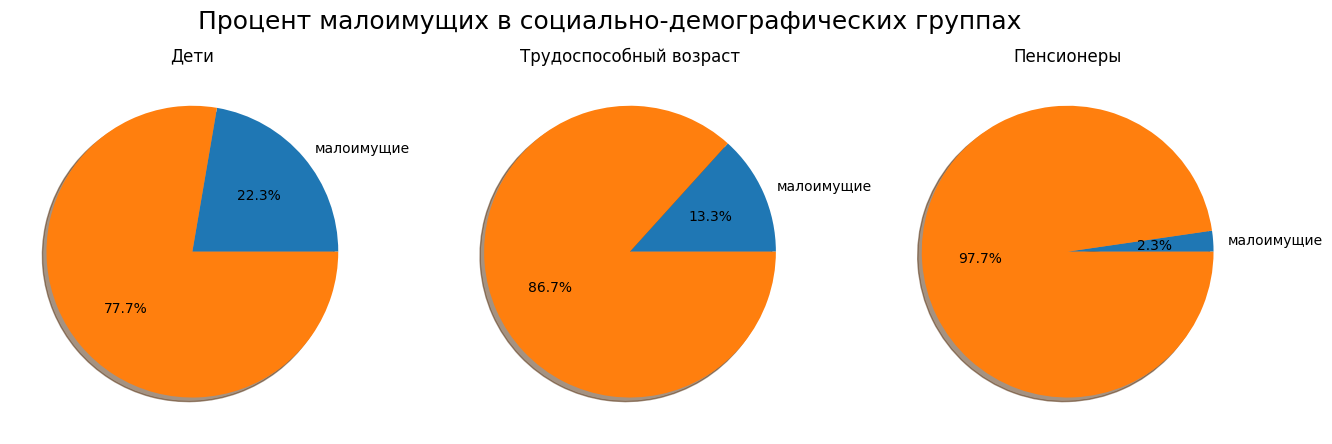

In [30]:
tmp_df = df_regions[['region', 'poverty_percent', 'poverty_socdem_16', 'poverty_socdem_retired', 'poverty_socdem_work', 'population_norm', 'child_count', 'retired_count']].set_index( 'region' )

# Восстановим численность населения по социальным группам 
tmp_df[ 'child_count' ] = round( tmp_df[ 'population_norm' ] * tmp_df[ 'child_count' ] / 100, 0 ).astype( 'int64' )
tmp_df[ 'retired_count' ] = round( tmp_df[ 'population_norm' ] * tmp_df[ 'retired_count' ] / 100, 0 ).astype( 'int64' )
tmp_df[ 'work_count' ] = tmp_df[ 'population_norm' ] - tmp_df[ 'child_count' ] - tmp_df[ 'retired_count' ]

# Восстановим численность населения за чертой бедности по социальным группам 
tmp_df[ 'poverty_socdem_child_count' ] = round( tmp_df[ 'poverty_socdem_16' ] * tmp_df['population_norm'] / 100, 0 ).astype( 'int64' )
tmp_df[ 'poverty_socdem_work_count' ] = round( tmp_df[ 'poverty_socdem_work' ] * tmp_df['population_norm'] / 100, 0 ).astype( 'int64' )
tmp_df[ 'poverty_socdem_retired_count' ] = round( tmp_df[ 'poverty_socdem_retired' ] * tmp_df['population_norm'] / 100, 0 ).astype( 'int64' )

# Группируем по всем регионвм
tmp_df = tmp_df.sum()

# Вычисляем общую долю  
proc_socdem_child = tmp_df[ 'poverty_socdem_child' ] = round( tmp_df[ 'poverty_socdem_child_count' ] * 100 / tmp_df['child_count'], 1 )
proc_socdem_work = tmp_df[ 'poverty_socdem_work' ] = round( tmp_df[ 'poverty_socdem_work_count' ] * 100 / tmp_df['work_count'], 1 )
proc_socdem_retired = tmp_df[ 'poverty_socdem_retired' ] = round( tmp_df[ 'poverty_socdem_retired_count' ] * 100 / tmp_df['retired_count'], 1 )

# Визуализируем
labels = ['малоимущие', '']
fig, ax = plt.subplots( 1, 3, figsize = (16,5) )

ax[0].pie( [proc_socdem_child, 100 - proc_socdem_child], labels = labels, autopct = '%1.1f%%', shadow = True )
ax[1].pie( [proc_socdem_work, 100 - proc_socdem_work], labels = labels, autopct = '%1.1f%%', shadow = True )
ax[2].pie( [proc_socdem_retired, 100 - proc_socdem_retired], labels = labels, autopct = '%1.1f%%', shadow = True );

ax[0].set_title( "Дети" )
ax[1].set_title( "Трудоспособный возраст" )
ax[2].set_title( "Пенсионеры" )
fig.suptitle( "Процент малоимущих в социально-демографических группах", fontsize = 18 )

А теперь посмотрим в разрезе по кластерам

Text(0.5, 0.98, 'Процент малоимущих в социально-демографических группах по кластерам')

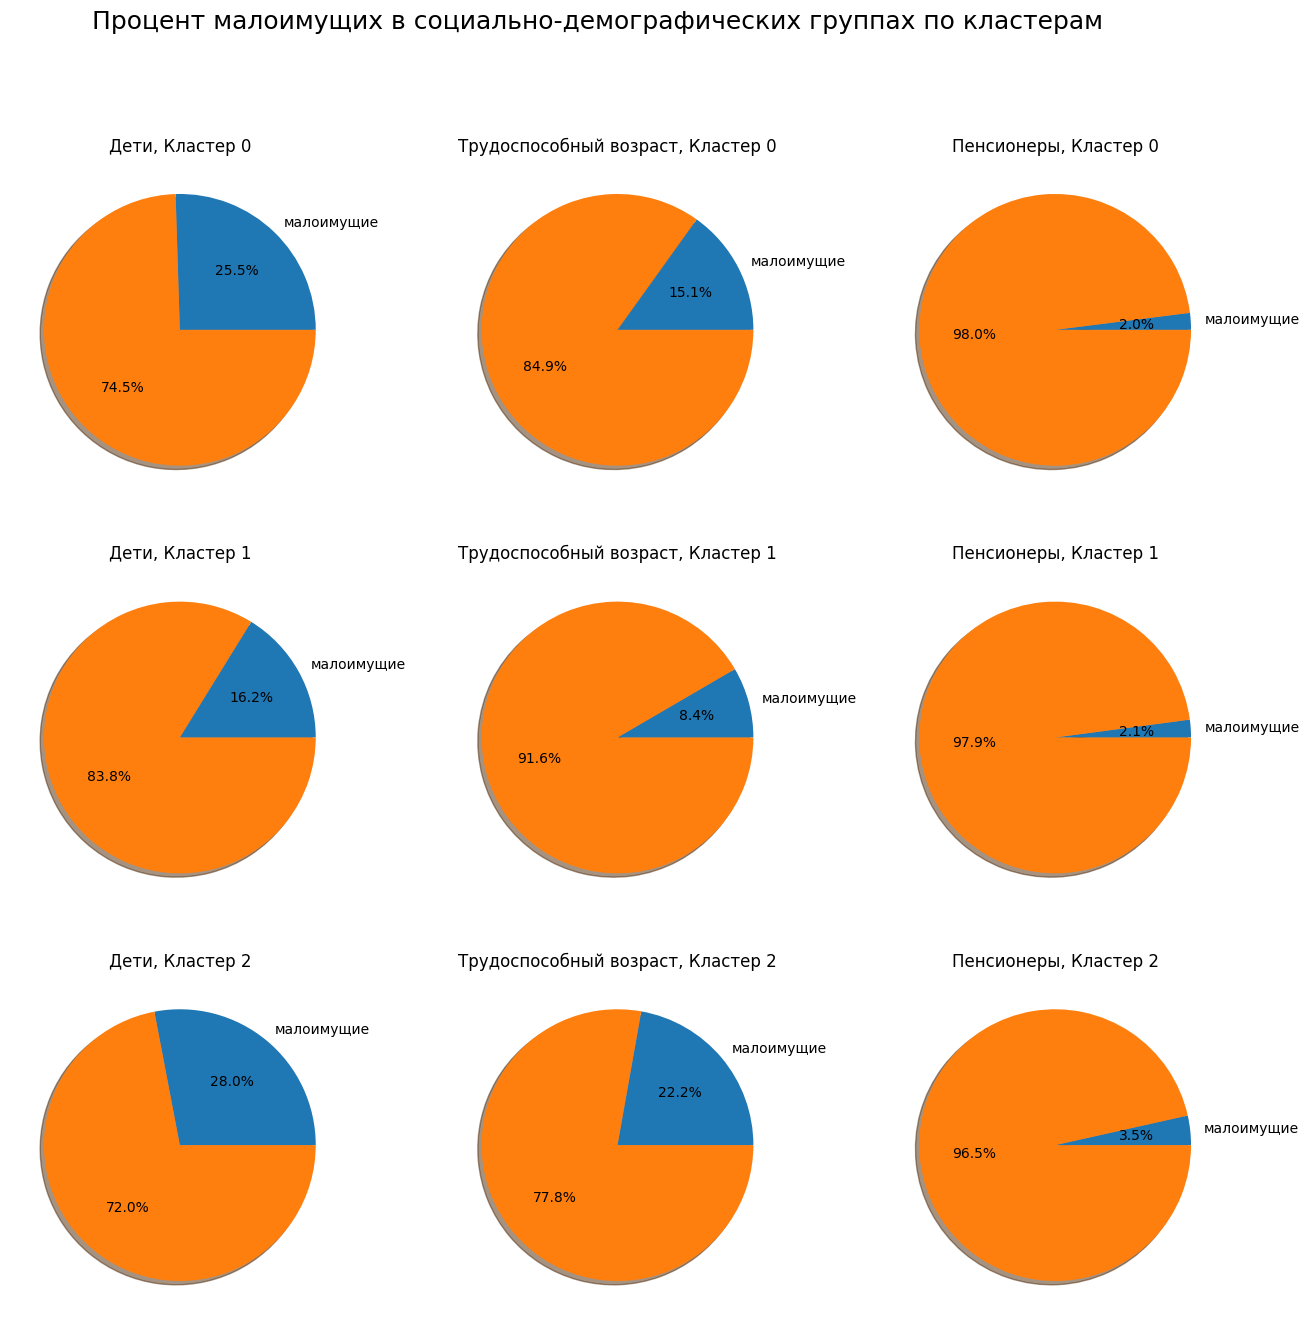

In [31]:
tmp_df = df_regions[['region', 'poverty_percent', 'poverty_socdem_16', 'poverty_socdem_retired', 'poverty_socdem_work', 'population_norm', 'child_count', 'retired_count', 'cluster']].set_index( 'region' )

# Восстановим численность населения по социальным группам 
tmp_df[ 'child_count' ] = round( tmp_df[ 'population_norm' ] * tmp_df[ 'child_count' ] / 100, 0 ).astype( 'int64' )
tmp_df[ 'retired_count' ] = round( tmp_df[ 'population_norm' ] * tmp_df[ 'retired_count' ] / 100, 0 ).astype( 'int64' )
tmp_df[ 'work_count' ] = tmp_df[ 'population_norm' ] - tmp_df[ 'child_count' ] - tmp_df[ 'retired_count' ]

# Восстановим численность населения за чертой бедности по социальным группам 
tmp_df[ 'poverty_socdem_child_count' ] = round( tmp_df[ 'poverty_socdem_16' ] * tmp_df['population_norm'] / 100, 0 ).astype( 'int64' )
tmp_df[ 'poverty_socdem_work_count' ] = round( tmp_df[ 'poverty_socdem_work' ] * tmp_df['population_norm'] / 100, 0 ).astype( 'int64' )
tmp_df[ 'poverty_socdem_retired_count' ] = round( tmp_df[ 'poverty_socdem_retired' ] * tmp_df['population_norm'] / 100, 0 ).astype( 'int64' )

# Группируем по всем регионам
tmp_df = tmp_df.groupby( 'cluster' ).sum()

# Вычисляем общую долю  
tmp_df["proc_socdem_child"] = tmp_df[ 'poverty_socdem_child' ] = round( tmp_df[ 'poverty_socdem_child_count' ] * 100 / tmp_df['child_count'], 1 )
tmp_df["proc_socdem_work"] = tmp_df[ 'poverty_socdem_work' ] = round( tmp_df[ 'poverty_socdem_work_count' ] * 100 / tmp_df['work_count'], 1 )
tmp_df["proc_socdem_retired"] = tmp_df[ 'poverty_socdem_retired' ] = round( tmp_df[ 'poverty_socdem_retired_count' ] * 100 / tmp_df['retired_count'], 1 )

# Визуализируем
labels = ['малоимущие', '']
fig, ax = plt.subplots( n_clusters, 3, figsize = (16,5 * n_clusters) )

for cluster, row in tmp_df.iterrows(): # По кластерам
    ax[cluster, 0].pie( [row["proc_socdem_child"], 100 - row["proc_socdem_child"] ], labels = labels, autopct = '%1.1f%%', shadow = True )
    ax[cluster, 1].pie( [row["proc_socdem_work"], 100 - row["proc_socdem_work"] ], labels = labels, autopct = '%1.1f%%', shadow = True )
    ax[cluster, 2].pie( [row["proc_socdem_retired"], 100 - row["proc_socdem_retired"] ], labels = labels, autopct = '%1.1f%%', shadow = True )
    ax[cluster, 0].set_title( f"Дети, Кластер {cluster}" )
    ax[cluster, 1].set_title( f"Трудоспособный возраст, Кластер {cluster}" )
    ax[cluster, 2].set_title( f"Пенсионеры, Кластер {cluster}" )
    
fig.suptitle( "Процент малоимущих в социально-демографических группах по кластерам", fontsize = 18 )


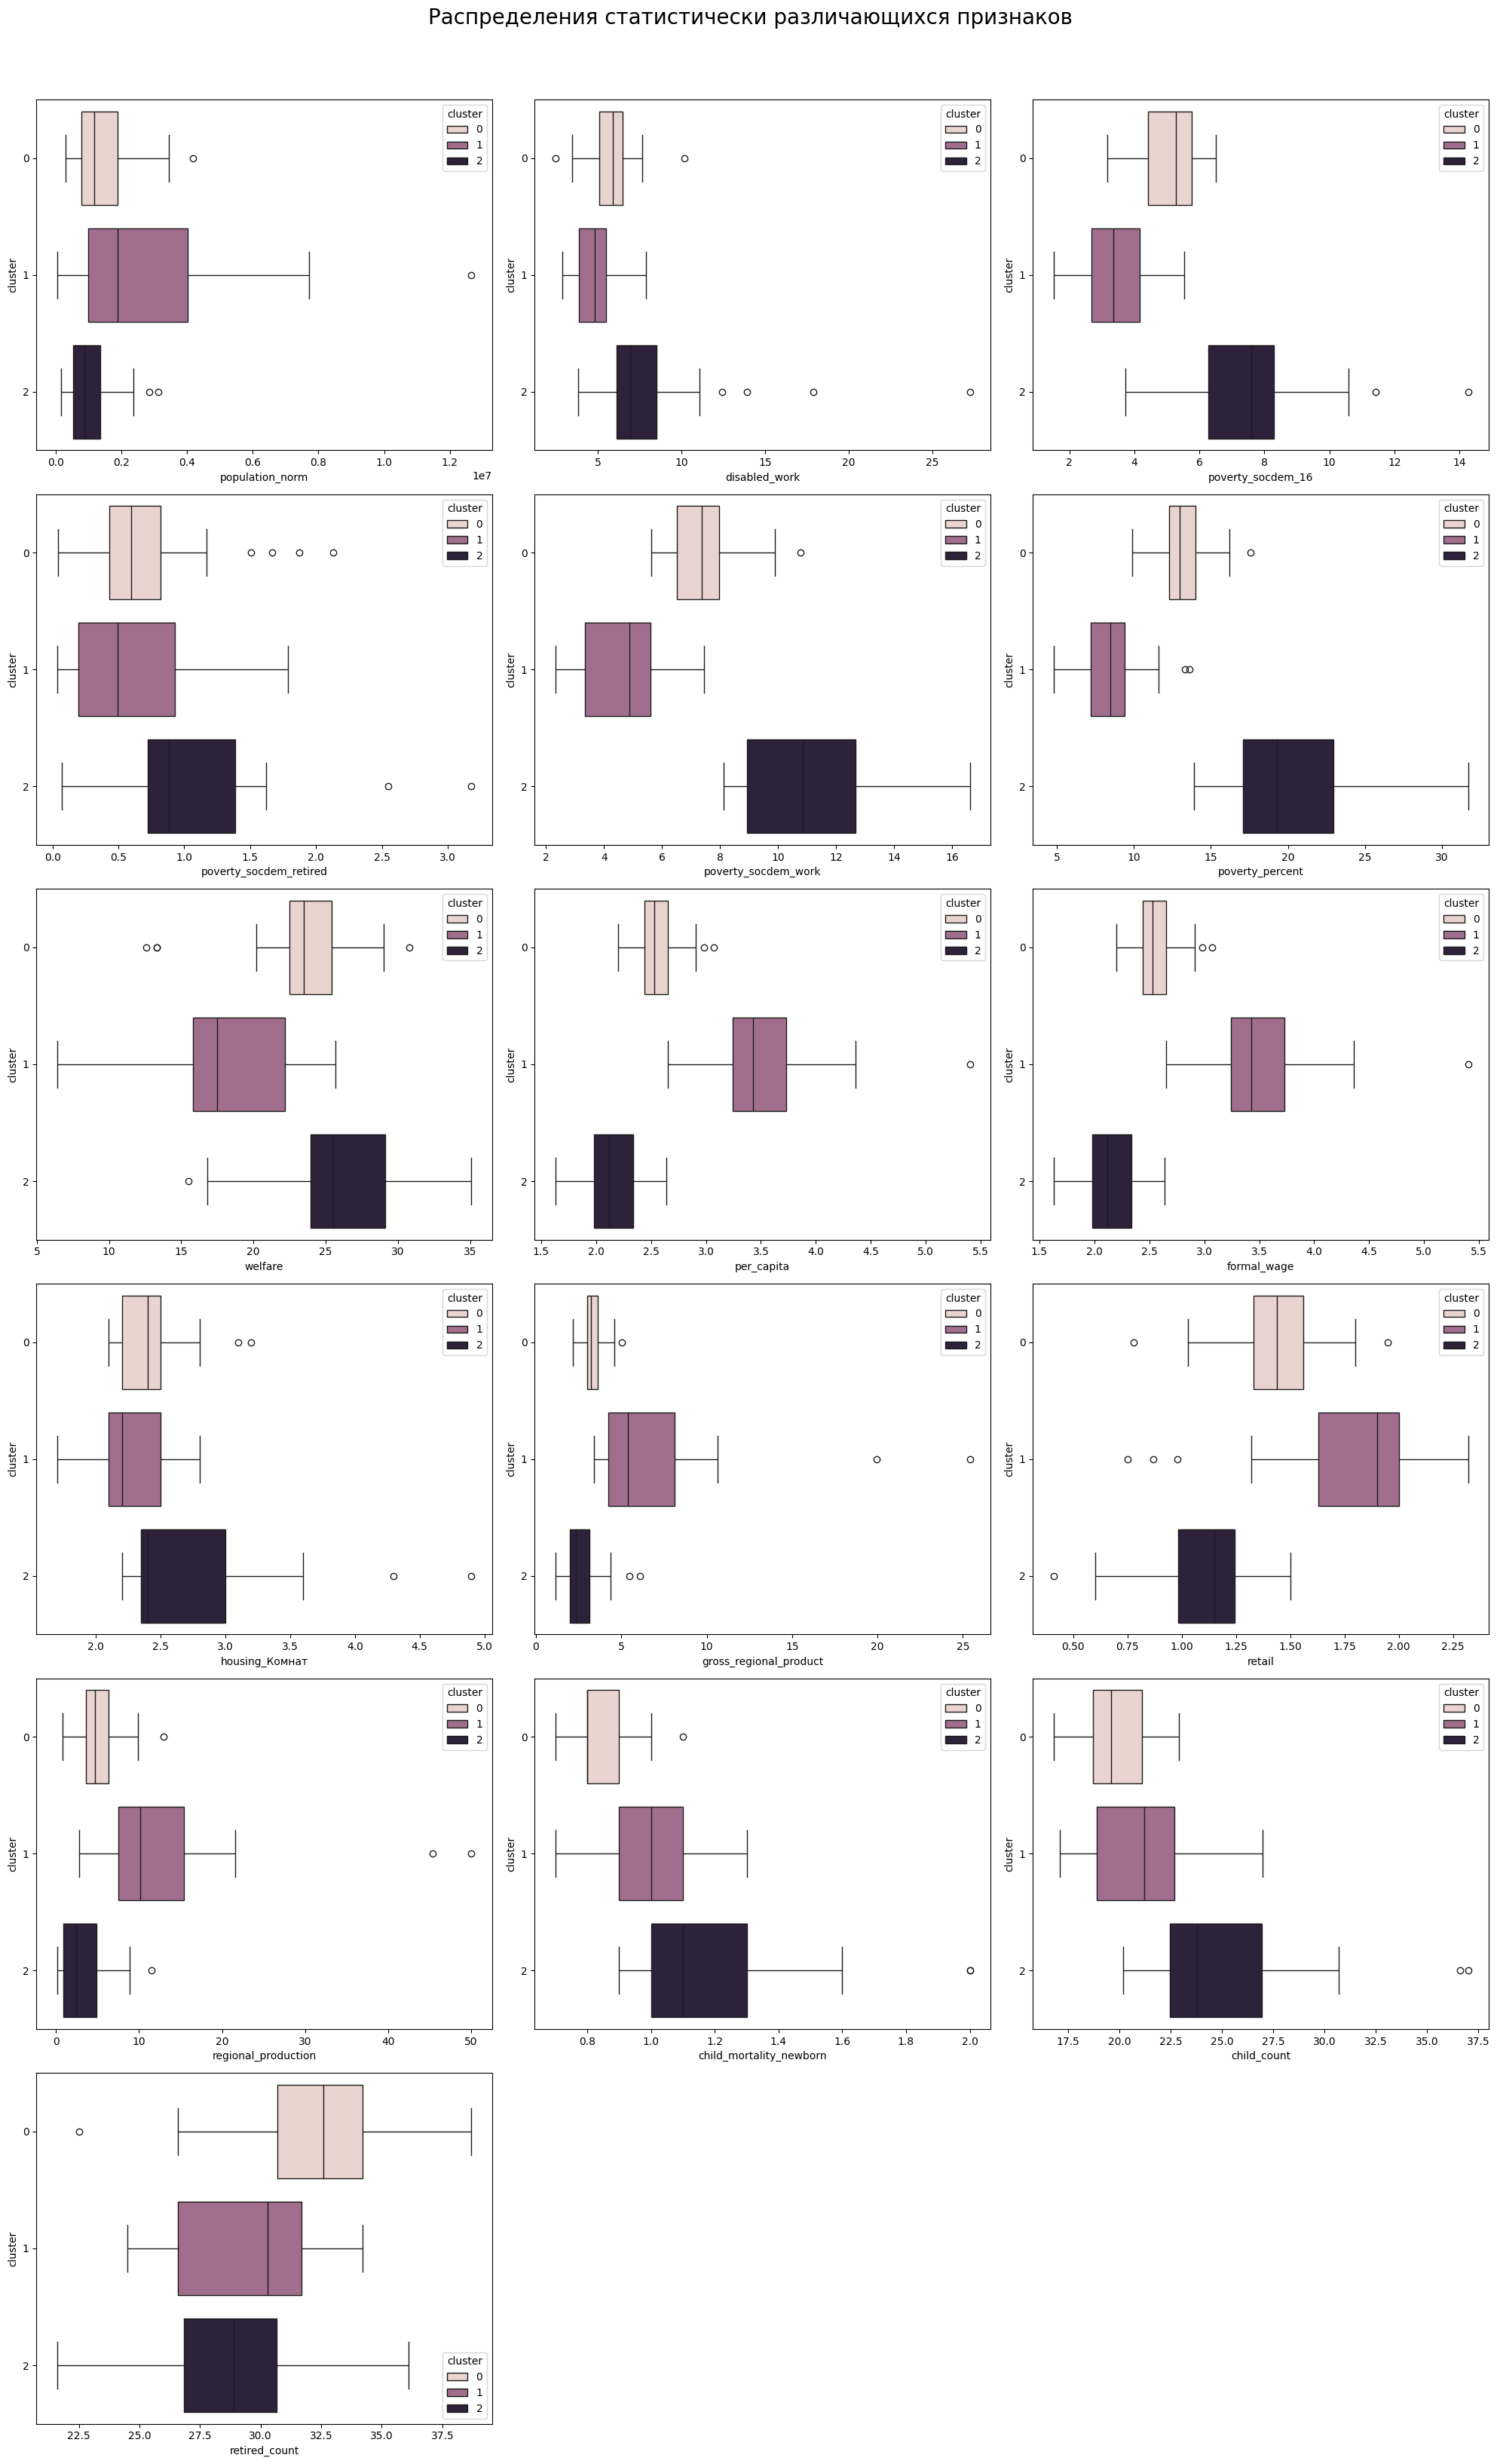

In [32]:
tmp_df = df_confirm[ (df_confirm['Вывод при alpha = 0.05'] == 'Различие статистически значимо') & ~df_confirm['Признак'].isin( ['lat','lon'] ) ].copy()

# Считаем размер сетки
n_rows = (tmp_df.shape[0] + 2) // 3
fig, ax = plt.subplots( n_rows, 3, figsize = (20, 2 * tmp_df.shape[0]) )

# Превращаем ax в одномерный массив для удобного обхода, если строк несколько
ax_flat = ax.flatten() if n_rows > 1 else [ax]

i = 0
for _, row in tmp_df.iterrows():
    col = row['Признак']
    sub_fig = sns.boxplot(
        data = df_regions,
        x = col,
        y = 'cluster',
        orient = 'h',
        hue = 'cluster',
        ax = ax_flat[i],
    )
    #sub_fig.set_title( f'Признак: {col}', fontsize = 12 )
    i += 1

# Скрываем лишние пустые оси, если сетка больше, чем число признаков
for j in range(i, len(ax_flat)):
    ax_flat[j].set_visible( False )

# Общий заголовок отчета
fig.suptitle( 'Распределения статистически различающихся признаков', fontsize = 20, y = 1.02 )

plt.tight_layout()
plt.show()

# Выводы

Получены кластеры регионов:

- Регионы со средними хараетеристиками
- Дотационные регионы
- Лидеры промышленности и инфраструктуры

На уровень бедности влияет 
- ВРП
- Объём производства
- Оборот розничной торговли
- Количество детей в семьях
- Количество пенсионеров в регионе
- Процент расходов на социальную политику от общих расходов бюджета региона
- Численность населения с инвалидностью
- Численность населения региона

На уровень бедности не влияет количество пенсионеров (есть стабильный источник доходов)


Малоимущие граждане по социальным группам: 
- Пенсионеров меньше всего и почти не зависит от кластеров. Это ожидаемо (имеют безусловный доход)
- Трудоспособного возраста среднее количество (разброс по кластерам ожижаемо выше). Не имеют безусловного дохода, но могут зарабатывыать деньги.
- Детского возраста больше всего. Не имеют безусловного дохода и не могут зарабатывыать деньги. Семьи с детьми наиболее уязвимы и требуют спец мер поддержки.

Нужно запускать производство в дотационных регионах, увеличивать рабочие места с конкуретноспособной зарплатой и развивать инфраструктуру.